In [ ]:
%pip install pandas numpy matplotlib seaborn corus pymorphy3 razdel nltk tqdm scikit-learn bertopic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.8 MB/s eta 0:00:00


In [273]:
import re
import gc
import html

import nltk
import torch
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import corus
import razdel
import pymorphy3
from razdel import tokenize
from nltk.corpus import stopwords

from collections import Counter

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
RANDOM_STATE = 42
DATASET_SIZE = 50_000

In [274]:
pd.set_option("display.max_colwidth", 120)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
!curl -L -O 'https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  502M  100  502M    0     0  35.1M      0  0:00:14  0:00:14 --:--:-- 39.9M


In [275]:
path = 'lenta-ru-news.csv.gz'
data = [item for i, item in enumerate(corus.load_lenta(path)) if i < DATASET_SIZE]
data[:5]

[LentaRecord(
     url='https://lenta.ru/news/2018/12/14/cancer/',
     title='Названы регионы России с\xa0самой высокой смертностью от\xa0рака',
     text='Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.',
     topic='Россия',
     tags='Общество',
     date=None
 ),
 LentaRecord(
     url='https://lenta.ru/news/2018/12/15/doping/',
     title='Австрия не\xa0представила доказательств

In [276]:
df = pd.DataFrame([{'title': r.title,'text': r.text, 'topic': r.topic} for r in data])
df.head()

,title,text,topic
0,Названы регионы России с самой высокой смертностью от рака,"Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высо...",Россия
1,Австрия не представила доказательств вины российских биатлонистов,Австрийские правоохранительные органы не представили доказательств нарушения российскими биатлонистами антидопинговы...,Спорт
2,Обнаружено самое счастливое место на планете,"Сотрудники социальной сети Instagram проанализировали поставленные пользователями смайлики, геолокации и хештеги и о...",Путешествия
3,В США раскрыли сумму расходов на расследование «российского дела»,С начала расследования российского вмешательства в выборы власти США потратили более 25 миллионов долларов. Об этом ...,Мир
4,Хакеры рассказали о планах Великобритании заминировать Севастополь,Хакерская группировка Anonymous опубликовала новые документы о деятельности британского аналитического центра Integr...,Мир


## Preprocessing

Перед применением BERTopic необходимо понять, требуется ли данным существенная предобработка.

Важно учитывать особенности алгоритма:
- BERTopic использует эмбеддинги предложений → сохраняется семантика текста
- чрезмерная очистка (лемматизация, агрессивное удаление слов) может ухудшить качество

Поэтому на данном этапе:
1. Проведем разведочный анализ данных (EDA)
2. Оценим необходимость предобработки
3. Выполним только релевантную очистку

In [277]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

print("Размер датасета:", df.shape)

display(df[["char_len", "word_len"]].describe().T)
display(df["topic"].value_counts().head(15).to_frame("count"))

Размер датасета: (50000, 5)


,count,mean,std,min,25%,50%,75%,max
char_len,50000.0,1263.27558,470.297704,252.0,971.75,1188.0,1466.0,9282.0
word_len,50000.0,172.75762,63.067476,31.0,133.00,163.0,200.0,1243.0


,count
topic,
Мир,6896
Россия,6871
Спорт,5458
Экономика,4915
Интернет и СМИ,3886
Наука и техника,3511
Из жизни,3319
Бывший СССР,3260
Культура,3171


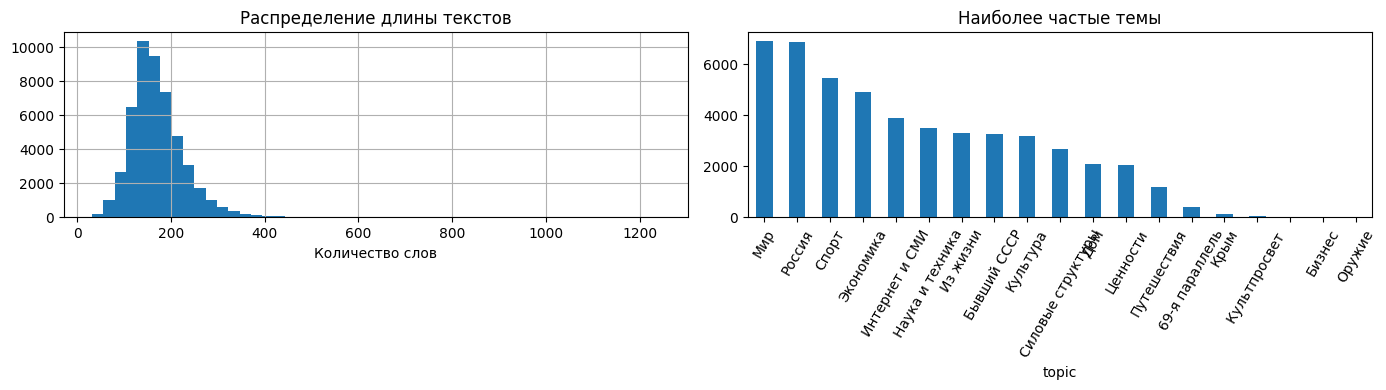

In [278]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# длина текстов
df["word_len"].hist(bins=50, ax=axes[0])
axes[0].set_title("Распределение длины текстов")
axes[0].set_xlabel("Количество слов")

# топ тем
df["topic"].value_counts().head(20).plot(kind="bar", ax=axes[1])
axes[1].set_title("Наиболее частые темы")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

- Тексты в среднем содержат ~100–200 слов → достаточно информативны
- Распределение тем сильно несбалансировано
- Имеет смысл избавить от шума в данных:
  - HTML/спецсимволы
  - ссылки
  - стоп-слова

### Вывод

Для BERTopic **не требуется жесткая предобработка**, поскольку:
- модель работает с эмбеддингами
- важно сохранить исходную семантику текста

В связи с этим проведем:
- удаление технического шума
- нормализацию текста
- фильтрацию коротких документов

In [279]:
def clean_text(text: str) -> str:
    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)
    text = text.lower()

    # ссылки и email
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # лишние символы
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [280]:
def make_document(row):
    title = clean_text(row["title"])
    body = clean_text(row["text"])

    if not body:
        return ""

    # избегаем дублирования заголовка
    if title and title not in body[:len(title) + 30]:
        return f"{title}. {body}"

    return body

In [281]:
df["document"] = df.apply(make_document, axis=1)
df.head()

,title,text,topic,char_len,word_len,document
0,Названы регионы России с самой высокой смертностью от рака,"Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высо...",Россия,660,92,названы регионы россии с самой высокой смертностью от рака. вице-премьер по социальным вопросам татьяна голикова рас...
1,Австрия не представила доказательств вины российских биатлонистов,Австрийские правоохранительные органы не представили доказательств нарушения российскими биатлонистами антидопинговы...,Спорт,1072,137,австрия не представила доказательств вины российских биатлонистов. австрийские правоохранительные органы не представ...
2,Обнаружено самое счастливое место на планете,"Сотрудники социальной сети Instagram проанализировали поставленные пользователями смайлики, геолокации и хештеги и о...",Путешествия,961,120,обнаружено самое счастливое место на планете. сотрудники социальной сети instagram проанализировали поставленные пол...
3,В США раскрыли сумму расходов на расследование «российского дела»,С начала расследования российского вмешательства в выборы власти США потратили более 25 миллионов долларов. Об этом ...,Мир,1347,190,в сша раскрыли сумму расходов на расследование «российского дела». с начала расследования российского вмешательства ...
4,Хакеры рассказали о планах Великобритании заминировать Севастополь,Хакерская группировка Anonymous опубликовала новые документы о деятельности британского аналитического центра Integr...,Мир,2066,255,хакеры рассказали о планах великобритании заминировать севастополь. хакерская группировка anonymous опубликовала нов...


In [282]:
MIN_LEN = 100

df = df[df["document"].str.len() > MIN_LEN].copy()
df = df.drop_duplicates(subset=["document"]).reset_index(drop=True)

print("После очистки:", df.shape)

После очистки: (49999, 6)


In [283]:
def tokenize_text(text: str):
    tokens = [t for t in text.split()]
    tokens = [
        t for t in tokens
        if re.match(r"[а-яa-z0-9-]+$", t)
        and len(t) >= 3
    ]

    return tokens

In [284]:
df["tokens"] = df["document"].apply(tokenize_text)

In [285]:
ru_stopwords = set(stopwords.words("russian"))

df["tokens_nostop"] = df["tokens"].apply(
    lambda tokens: [t for t in tokens if t not in ru_stopwords]
)

Проанализиурем частоту слов

In [286]:
token_freq = Counter(
    token for doc in df["tokens_nostop"] for token in doc
)

freq_df = pd.DataFrame(token_freq.most_common(30), columns=["token", "freq"])
display(freq_df)

,token,freq
0,также,25212
1,россии,21951
2,это,21160
3,сообщает,18727
4,года,18182
5,время,15668
6,сша,12776
7,которые,11756
8,году,11160
9,который,11066


Анализ частотных слов показал наличие большого количества типичных маркеров новостного домена. Такие слова часто попадают в топики, но не несут особого смысла.

Составим небольшой список доменно-специфичных стоп-слов. Это не влияет на тексты, используемые для эмбеддингов, но делает описание тем более интерпретируемым.

In [287]:
# доменные
news_stopwords = {
    "также", "это", "который", "которые",
    "сообщает", "заявил", "сказал", "рассказал",
    "словам", "однако", "около",
    "года", "году", "лет", "время",
    "тысяч", "миллионов",
    "2017", "2018"
}

In [288]:
df["tokens_clean"] = df["tokens_nostop"].apply(
    lambda tokens: [t for t in tokens if t not in news_stopwords]
)

In [289]:
df["doc_to_vect"] = df["tokens_clean"].apply(" ".join)

In [290]:
df[["document", "doc_to_vect"]].head()

,document,doc_to_vect
0,названы регионы россии с самой высокой смертностью от рака. вице-премьер по социальным вопросам татьяна голикова рас...,названы регионы россии самой высокой смертностью вице-премьер социальным вопросам татьяна голикова каких регионах ро...
1,австрия не представила доказательств вины российских биатлонистов. австрийские правоохранительные органы не представ...,австрия представила доказательств вины российских австрийские правоохранительные органы представили доказательств на...
2,обнаружено самое счастливое место на планете. сотрудники социальной сети instagram проанализировали поставленные пол...,обнаружено самое счастливое место сотрудники социальной сети instagram проанализировали поставленные пользователями ...
3,в сша раскрыли сумму расходов на расследование «российского дела». с начала расследования российского вмешательства ...,сша раскрыли сумму расходов расследование начала расследования российского вмешательства выборы власти сша потратили...
4,хакеры рассказали о планах великобритании заминировать севастополь. хакерская группировка anonymous опубликовала нов...,хакеры рассказали планах великобритании заминировать хакерская группировка anonymous опубликовала новые документы де...


## BERTopic

Для тематического моделирования используется библиотека BERTopic, которая объединяет несколько этапов:

1. Получение эмбеддингов документов
2. Снижение размерности
3. Кластеризация документов
4. Извлечение интерпретируемых токенов тем

### Выбор компонентов

- **Энкодер**: `paraphrase-multilingual-MiniLM-L12-v2`  
  Лёгкая multilingual модель. Легче и быстрее чем та же E5-multilingual, но должна неплохо справлять с русским.

- **Снижение размерности**: PCA  
  Более стабильный и быстрый вариант по сравнению с UMAP.

- **Кластеризация**: KMeans  
  Проще и предсказуемее, чем HDBSCAN, не требует сложной настройки.

- **Векторизация**: CountVectorizer + стоп-слова

In [291]:
docs = df["document"].tolist()

In [292]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings = np.asarray(embeddings, dtype=np.float32)
print(embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

(49999, 384)


### Baseline

In [293]:
all_stopwords = ru_stopwords | news_stopwords

In [294]:
# Vectorizer
vectorizer_model = CountVectorizer(
    stop_words=list(all_stopwords),
    ngram_range=(1, 1),
    min_df=10,
    max_df=0.8
)

# c-TF-IDF
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

# PCA
pca_model = PCA(
    n_components=5,
    random_state=RANDOM_STATE
)

# KMeans
kmeans_model = KMeans(
    n_clusters=50,
    random_state=RANDOM_STATE,
    n_init=10
)

# BERTopic
topic_model = BERTopic(
    embedding_model=None,
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(docs, embeddings)

2026-04-05 15:53:49,551 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 15:53:49,728 - BERTopic - Dimensionality - Completed ✓
2026-04-05 15:53:49,732 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 15:54:00,507 - BERTopic - Cluster - Completed ✓
2026-04-05 15:54:00,521 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 15:54:03,406 - BERTopic - Representation - Completed ✓


In [295]:
df["topic"] = topics

In [296]:
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

n_topics = len(topic_info[topic_info.Topic != -1])
print("Число тем:", n_topics)

,Topic,Count,Name,Representation,Representative_Docs
0,0,1619,0_wada_newsone_ua_ibu,"[wada, newsone, ua, ibu, cas, 20132014, g20, 322, zik, 7669]",[россиянку обвинили во вмешательстве в выборы сша 2018 года. гражданка россии елена хусяйнова пыталась повлиять на в...
1,1,1310,1_g20_javelin_g7_1987,"[g20, javelin, g7, 1987, 1112, 1400, 1956, gps, malaysia, juncture]",[в кремле подтвердили возможное место встречи путина и трампа. президент россии владимир путин и президент сша донал...
2,2,1269,2_show_tinder_its_love,"[show, tinder, its, love, this, that, my, buzzfeed, not, good]",[раскрыты предсмертные планы солистки the cranberries. лидер метал-группы bad wolves томми векст рассказал о планах ...
3,3,1253,3_162_293_111_911,"[162, 293, 111, 911, angeles, ctv, parisien, zizzi, abc, 1718]","[озверевшая из-за проблем с мужем китаянка покусала попутчика. в китае эвакуировали поезд после того, как пассажирка..."
4,4,1224,4_ua_282_bellingcat_really,"[ua, 282, bellingcat, really, fm, hermitage, roshen, newsone, siemens, 777]",[лидера «русской республики» посадили за оправдание брейвика в соцсети. в архангельской области вступил в силу обвин...
5,5,1188,5_hbo_upi_emirates_marvel,"[hbo, upi, emirates, marvel, pictures, id, airlines, mashable, easyjet, iphone]",[авиакомпания заставила пассажиров плакать. британский авиаперевозчик virgin atlantic запустил необычный социальный ...
6,6,1182,6_marca_mma_espn_wba,"[marca, mma, espn, wba, ufc, football, sports, sportsru, my, wbc]",[кличко посмотрел бой поветкина с джошуа и пожалел о завершении карьеры. мэр киева и бывший боксер-тяжеловес виталий...
7,7,1175,7_medicalxpress_vuitton_louis_chanel,"[medicalxpress, vuitton, louis, chanel, balenciaga, eurekalert, supreme, pornhub, nike, offwhite]",[голубого медведя louis vuitton в футболке supreme продадут ради детей. французский модный дом louis vuitton выпусти...
8,8,1166,8_lil_tmz_los_angeles,"[lil, tmz, los, angeles, mirror, hollywood, chicago, david, herald, reporter]",[названа причина смерти эмо-рэпера lil peep. полиция раскрыла подробности и наиболее вероятную причину смерти америк...
9,9,1146,9_pdt_vogue_by_on,"[pdt, vogue, by, on, secret, victorias, be, girls, look, you]","[популярная модель оказалась ненастоящей. бразильско-американская модель по имени лил микуэла, которая прославилась ..."


Число тем: 50


### Тюнинг

Подбираем гиперпараметры на подвыборке данных.

Сравниваем конфигурации по:
- UMass coherence
- Topic diversity
- покрытию документов

Критерий выбора:
в первую очередь UMass coherence, при близких значениях — diversity.

In [297]:
def get_words_per_cluster(mdl, n_words=10):
    info = mdl.get_topic_info()
    ids = [tid for tid in info["Topic"].tolist() if tid != -1]
    return {
        tid: [w for w, _ in mdl.get_topic(tid)[:n_words]]
        for tid in ids
    }


def lexical_variety(mdl, n_words=10):
    clusters = get_words_per_cluster(mdl, n_words)
    all_words = []
    for wlist in clusters.values():
        all_words.extend(wlist)
    if not all_words:
        return np.nan
    return len(set(all_words)) / len(all_words)


def pairwise_umass(mdl, corpus, vec_model, n_words=10):
    fitted_vec = clone(vec_model)
    term_matrix = fitted_vec.fit_transform(corpus)
    binary_matrix = (term_matrix > 0).astype(np.int32).tocsc()

    word_index = fitted_vec.vocabulary_
    df = np.asarray(binary_matrix.sum(axis=0)).ravel()

    clusters = get_words_per_cluster(mdl, n_words)

    scores_by_cluster = []
    for word_list in clusters.values():
        col_ids = [word_index[w] for w in word_list if w in word_index]
        if len(col_ids) < 2:
            continue

        pair_log_scores = [
            np.log(
                (binary_matrix[:, col_ids[i]].multiply(binary_matrix[:, col_ids[j]]).sum() + 1)
                / (df[col_ids[j]] if df[col_ids[j]] > 0 else 1)
            )
            for i in range(1, len(col_ids))
            for j in range(i)
        ]

        if pair_log_scores:
            scores_by_cluster.append(float(np.mean(pair_log_scores)))

    return float(np.mean(scores_by_cluster)) if scores_by_cluster else np.nan


def evaluate_topic_model(topic_model, docs, topics, vectorizer_model, top_n_words=10):
    arr = np.asarray(topics)
    valid_mask = arr != -1

    n_topics = len(set(arr[valid_mask].tolist()))
    coverage = float(valid_mask.mean()) if arr.size else np.nan
    outlier_share = (1.0 - coverage) if not np.isnan(coverage) else np.nan

    return {
        "n_topics":         n_topics,
        "coverage":         coverage,
        "outlier_share":    outlier_share,
        "topic_diversity":  lexical_variety(topic_model, top_n_words),
        "u_mass_coherence": pairwise_umass(topic_model, docs, vectorizer_model, top_n_words),
    }

In [298]:
TUNE_DOCS = 10_000

rng = np.random.default_rng(RANDOM_STATE)
tune_idx = np.sort(rng.choice(len(docs), size=TUNE_DOCS, replace=False))

tune_docs = [docs[i] for i in tune_idx]
tune_embeddings = embeddings[tune_idx]

In [299]:
candidate_configs = {
    "small": {
        "n_topics": 30,
        "n_components": 5,
        "ngram_range": (1, 1),
        "min_df": 10,
        "max_df": 0.8,
        "max_features": 30000,
    },
    "balanced": {
        "n_topics": 50,
        "n_components": 8,
        "ngram_range": (1, 2),
        "min_df": 5,
        "max_df": 0.9,
        "max_features": 50000,
    },
    "detailed": {
        "n_topics": 70,
        "n_components": 10,
        "ngram_range": (1, 2),
        "min_df": 5,
        "max_df": 0.9,
        "max_features": 60000,
    },
}

In [300]:
def build_topic_model(config):
    vectorizer_model = CountVectorizer(
        stop_words=list(all_stopwords),
        ngram_range=config["ngram_range"],
        min_df=config["min_df"],
        max_df=config["max_df"],
        max_features=config["max_features"],
    )

    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

    dim_model = PCA(
        n_components=config["n_components"],
        random_state=RANDOM_STATE,
    )

    cluster_model = KMeans(
        n_clusters=config["n_topics"],
        n_init=10,
        random_state=RANDOM_STATE,
    )

    topic_model = BERTopic(
        embedding_model=None,
        umap_model=dim_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        verbose=False,
    )

    return topic_model

### Перебор конфигураций

In [301]:
tuning_rows = []

for name, config in candidate_configs.items():
    print(f"\n=== CONFIG: {name} ===")

    model = build_topic_model(config)

    topics, _ = model.fit_transform(tune_docs, tune_embeddings)

    metrics = evaluate_topic_model(
        topic_model=model,
        docs=tune_docs,
        topics=topics,
        vectorizer_model=model.vectorizer_model,
        top_n_words=10,
    )

    row = {
        "config_name": name,
        **config,
        **metrics
    }

    tuning_rows.append(row)

    print(metrics)

    del model, topics
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


=== CONFIG: small ===
{'n_topics': 30, 'coverage': 1.0, 'outlier_share': 0.0, 'topic_diversity': 0.6733333333333333, 'u_mass_coherence': -3.083474490818034}

=== CONFIG: balanced ===
{'n_topics': 50, 'coverage': 1.0, 'outlier_share': 0.0, 'topic_diversity': 0.854, 'u_mass_coherence': -2.439048380320821}

=== CONFIG: detailed ===
{'n_topics': 70, 'coverage': 1.0, 'outlier_share': 0.0, 'topic_diversity': 0.8628571428571429, 'u_mass_coherence': -2.3253022593710586}


In [302]:
tuning_df = pd.DataFrame(tuning_rows)

tuning_df = tuning_df.sort_values(
    by=["u_mass_coherence", "topic_diversity"],
    ascending=False
).reset_index(drop=True)

tuning_df

,config_name,n_topics,n_components,ngram_range,min_df,max_df,max_features,coverage,outlier_share,topic_diversity,u_mass_coherence
0,detailed,70,10,"(1, 2)",5,0.9,60000,1.0,0.0,0.862857,-2.325302
1,balanced,50,8,"(1, 2)",5,0.9,50000,1.0,0.0,0.854000,-2.439048
2,small,30,5,"(1, 1)",10,0.8,30000,1.0,0.0,0.673333,-3.083474


Выбрана конфигурация **detailed**, так как она показывает наилучшее значение UMass coherence и максимальную topic diversity при полном покрытии данных.  
Это указывает на более качественное и разнообразное разделение тем по сравнению с другими вариантами.

### Обучим лучшую BERTopic модель на всех данных

In [303]:
best_model = build_topic_model(candidate_configs['detailed'])
topics, _ = best_model.fit_transform(docs, embeddings)

topic_info = best_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,0,1167,0_cas_cas cas_ufc_ufc ufc,"[cas, cas cas, ufc, ufc ufc, com, ibu, mma, ufc 229, wada, cas 28]",[отец нурмагомедова допустил уход бойца из ufc. отец российского бойца смешанного стиля (mma) хабиба нурмагомедова а...
1,1,1037,1_g20_g7_bear_bear cozy,"[g20, g7, bear, bear cozy, cozy, cozy bear, 16 g20, g20 30, 26 60, 2008 2012]",[сша пообещали не вмешиваться в российские выборы. сша считают выборы президента россии 2018 года внутренним делом с...
2,2,984,2_newsone_112 youtube_31 2019_ua,"[newsone, 112 youtube, 31 2019, ua, 2014 2014, 112, 2014 facebook, 1925, 1943, zik]","[в польше нашли способ отсеивать въезжающих украинцев. польские власти начали спрашивать украинцев, подающих заявку ..."
3,3,952,3_brent_fitch_urals_frank,"[brent, fitch, urals, frank, lynch, knight frank, knight, wti, 05, headhunter]",[назван самый популярный подержанный автомобиль в россии. самым популярным подержанным автомобилем в россии стала la...
4,4,929,4_plussize_pdt_on_you,"[plussize, pdt, on, you, to, is, vogue, and, body, was]","[блогер поделилась секретом ликвидации жирных боков. австралийская блогер бек джексон (beck jackson) рассказала, что..."
5,5,899,5_hollywood reporter_reporter_hollywood_the hollywood,"[hollywood reporter, reporter, hollywood, the hollywood, comedy, 50 cent, cent, comedy club, netflix, radiohead]",[ума турман обвинила вайнштейна в домогательствах и разочаровала его. актриса ума турман рассказала о домогательства...
6,6,896,6_11 45_kronen_kronen zeitung_103,"[11 45, kronen, kronen zeitung, 103, 11 47, 80 47, 18 18, g20, putin team, iv]",[крупнейшая газета финляндии обратилась к путину и трампу. крупнейшая газета финляндии helsingin sanomat опубликовал...
7,7,884,7_57 57_f35_f22_lightning ii,"[57 57, f35, f22, lightning ii, lightning, national interest, interest, f35 lightning, the national, f22 raptor]",[сша нашли в россии «убийцу» f-35. создаваемые в россии радиофотонные радиолокационные станции действительно могут с...
8,8,882,8_pdt_vuitton_louis vuitton_louis,"[pdt, vuitton, louis vuitton, louis, nike, chanel, balenciaga, montblanc, boss, vacheron constantin]",[louis vuitton останется без дизайнера. дизайнер мужских коллекций французского дома louis vuitton ким джонс покидае...
9,9,863,9_hbo_upi_nissan_gopro,"[hbo, upi, nissan, gopro, iphone, reddit, hbo 2011, samsung, apple iphone, apple]","[канье уэст зачитал о трампе, наркотиках и болезни в новом альбоме. рэпер канье уэст представил свой новый альбом ye..."


In [304]:
result_metrics = evaluate_topic_model(
    topic_model=best_model,
    docs=docs,
    topics=topics,
    vectorizer_model=best_model.vectorizer_model,
    top_n_words=10,
)

pd.DataFrame([result_metrics])

,n_topics,coverage,outlier_share,topic_diversity,u_mass_coherence
0,70,1.0,0.0,0.834286,-3.240314


### Топ-токены для каждого топика

In [305]:
def get_topic_top_words(topic_model, top_n=10):
    topic_info = topic_model.get_topic_info()

    topics = []

    for topic_id in topic_info["Topic"]:
        if topic_id == -1:
            continue

        words = topic_model.get_topic(topic_id)[:top_n]

        topics.append({
            "topic_id": topic_id,
            "words": ", ".join([w for w, _ in words])
        })

    return pd.DataFrame(topics)

In [306]:
top_words_df = get_topic_top_words(best_model, top_n=10)
top_words_df.head(10)

,topic_id,words
0,0,"cas, cas cas, ufc, ufc ufc, com, ibu, mma, ufc 229, wada, cas 28"
1,1,"g20, g7, bear, bear cozy, cozy, cozy bear, 16 g20, g20 30, 26 60, 2008 2012"
2,2,"newsone, 112 youtube, 31 2019, ua, 2014 2014, 112, 2014 facebook, 1925, 1943, zik"
3,3,"brent, fitch, urals, frank, lynch, knight frank, knight, wti, 05, headhunter"
4,4,"plussize, pdt, on, you, to, is, vogue, and, body, was"
5,5,"hollywood reporter, reporter, hollywood, the hollywood, comedy, 50 cent, cent, comedy club, netflix, radiohead"
6,6,"11 45, kronen, kronen zeitung, 103, 11 47, 80 47, 18 18, g20, putin team, iv"
7,7,"57 57, f35, f22, lightning ii, lightning, national interest, interest, f35 lightning, the national, f22 raptor"
8,8,"pdt, vuitton, louis vuitton, louis, nike, chanel, balenciaga, montblanc, boss, vacheron constantin"
9,9,"hbo, upi, nissan, gopro, iphone, reddit, hbo 2011, samsung, apple iphone, apple"


In [307]:
fig = best_model.visualize_barchart(top_n_topics=15, n_words=10, title="Топ-слова по темам")
fig.show()

### Документы с их топиками в 2D пространстве

In [308]:
sample_n = 3000

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = np.sort(rng.choice(len(docs), size=sample_n, replace=False))

sample_embeddings = embeddings[sample_idx]
sample_topics = np.asarray([df.iloc[i]["topic"] for i in sample_idx])

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
sample_2d = pca_2d.fit_transform(sample_embeddings)

vis_df = pd.DataFrame({
    "x": sample_2d[:, 0],
    "y": sample_2d[:, 1],
    "topic_id": sample_topics.astype(str),
})

fig = px.scatter(
    vis_df,
    x="x",
    y="y",
    color="topic_id",
    title="Documents in 2D space (PCA, sampled)",
    width=1200,
    height=800,
)

fig.show()

### Распределение тем по токенам для выборочных текстов из датасета

In [309]:
sample_n = 5

sample_indices = np.random.choice(len(docs), size=sample_n, replace=False)
sample_docs = [docs[i] for i in sample_indices]

topics, probs = best_model.transform(sample_docs, embeddings[sample_indices])

In [310]:
vectorizer = best_model.vectorizer_model

for i, doc in enumerate(sample_docs):
    print("=" * 80)
    print(f"Document {i}, topic: {topics[i]}")

    tokens = vectorizer.build_analyzer()(doc)
    tokens = list(set(tokens))[:20]

    print("Tokens:", tokens)

    if probs is not None:
        topic_probs = probs[i]
        top_topics = np.argsort(topic_probs)[::-1][:5]

        print("\nTop topics:")
        for t in top_topics:
            print(f"Topic {t}: {topic_probs[t]:.4f}")

Document 0, topic: 36
Tokens: ['набрать высоту', 'отлов бездомных', 'собак будут', 'взлетно', 'разогнали', 'коми', 'телеканал юрган', 'собаки помешали', 'кружить', 'несколько городе', 'ухты республика', 'бродившая взлетно', 'ухте', 'ухты', 'пришлось набрать', 'движение самолета', 'города', 'будут', 'движение', 'самолета опасался']
Document 1, topic: 25
Tokens: ['россии', 'позволяющих', 'проектов представляемых', 'институтов', 'свобод человека', 'проекты', 'направлений поддержка', 'трех поддержаны', 'подписал', 'проектов', 'поддержка молодых', 'первом конкурсе', 'проводиться', 'некоммерческих организаций', 'рамках нового', 'полтора', 'человека', 'конкурсов', 'искусства', 'изменились']
Document 2, topic: 56
Tokens: ['news', 'австралийском', 'программы outsiders', 'намерения', 'типичным', 'стороны', 'бывший', 'мужчина делал', 'прямом', 'косоглазых китайцах', 'news вышла', 'пол уиттакер', 'комментарии относительно', 'джексона', 'добавил', 'высказывания', 'пытающихся попасть', 'женщинах обв

Видим, что для разных документов модель неплохо выделяет тематические кластеры: в токенах хорошо прослеживаются ключевые слова, связанные с соответствующими темами (например, уход/волосы, политика, социальные вопросы и т.д.).

### Финальные результаты

In [311]:
results = pd.DataFrame([result_metrics])
results

,n_topics,coverage,outlier_share,topic_diversity,u_mass_coherence
0,70,1.0,0.0,0.834286,-3.240314


## Выводы

В целом выбранный пайплайн **BERTopic** с **PCA** и **KMeans** отработал довольно неплохо.

На метриках видим результат: Topic Diversity = **0.834** говорит о том, что темы достаточно различаются между собой и не дублируют друг друга, а UMass Coherence = **-3.24** указывает на умеренную, но не идеальную связность топ-слов внутри тем.

Результат можно считать рабочим: модель улавливает структуру корпуса и формирует осмысленные группы документов, хотя качество тем и их связность остаются умеренными и могут быть улучшены при более качественной настройке параметров и выборе более продвинутых и тяжелых эмбеддингов.